In [9]:
from pylib.setup import *
setup_notebook()

from assumptions import demand, solar_tech, wind_tech, battery
from model import GridSupply, VESupply

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Lastprofil og eksport — VE-scenariet

Viser time-for-time, hvordan datacentrets efterspørgsel på 1 GW mødes i VE-scenariet.
For hver time dekomponeres leveringen i fire kilder: solkraft, vindkraft, batteri (udladning) og netimport.
Under nul vises eksport af overskudsproduktion til spotpris, begrænset af nettilslutningskapaciteten $(1-x) \cdot P = 500$ MW.

*`1. inputdata`*

*Indlæser de tre 8 760-rækkers inputfiler og normaliserer til kapacitetsfaktorer og EUR/MWh.*

In [10]:
# 1. inputdata
pat           = pathlib.Path('variation_patterns')
_solar_cap_mw = 4_955.5428
_wind_cap_mw  = 4_878.483

solar_cf = np.loadtxt(pat / 'PV_VE_2025_2026.txt') / _solar_cap_mw
wind_cf  = np.loadtxt(pat / 'WL_VE_2025_2026.txt') / _wind_cap_mw
prices   = np.loadtxt(pat / 'wp_2025_2026.txt')    / 7.46

print(f'solar_cf  mean={solar_cf.mean():.3f}  max={solar_cf.max():.3f}')
print(f'wind_cf   mean={wind_cf.mean():.3f}  max={wind_cf.max():.3f}')
print(f'prices    mean={prices.mean():.1f}  min={prices.min():.1f}  max={prices.max():.1f} EUR/MWh')

solar_cf  mean=0.103  max=0.750
wind_cf   mean=0.229  max=0.816
prices    mean=81.6  min=-30.7  max=583.5 EUR/MWh


*`2. byg model og optimér`*

*Initialiserer modellag og kører VE-optimeringen: Nelder-Mead over $(C_\text{sol}, C_\text{vind}, P_\text{bat})$ med indre bisektionsprocedure for $E_\text{bat}$. Tager typisk 20–40 s.*

In [11]:
# 2. byg model og optimér
grid = GridSupply(prices, demand)
ve   = VESupply(solar_cf, wind_cf, solar_tech, wind_tech, battery, demand, prices=prices)

t0 = time.time()
c_solar, c_wind, batt_power, batt_energy = ve.solution
print(f'Optimering afsluttet på {time.time()-t0:.1f} s')
print(f'  Solkraft : {c_solar:,.0f} MW')
print(f'  Vindkraft: {c_wind:,.0f} MW')
print(f'  Batteri  : {batt_power:,.0f} MW / {batt_energy:,.0f} MWh')

Optimering afsluttet på 49.8 s
  Solkraft : 4,620 MW
  Vindkraft: 3,539 MW
  Batteri  : 500 MW / 30,036 MWh


*`3. hjælpefunktioner`*

*Definerer `dispatch_detail`, `aggregate_dispatch` og `plot_dispatch` — alle tre kan flyttes til en py-fil uden ændringer.*

In [12]:
# 3. hjælpefunktioner
# dispatch_detail, aggregate_dispatch, plot_dispatch injected by setup_notebook()

# ── compute ───────────────────────────────────────────────────────────────────
dates = pd.date_range('2025-01-01', periods=8760, freq='h')
d     = dispatch_detail(ve, solar_cf, wind_cf)

print(f"Solkraft til forbrug  : {d['pv'].sum()/1e6:.2f} TWh/år")
print(f"Vindkraft til forbrug : {d['wind'].sum()/1e6:.2f} TWh/år")
print(f"Batteri til forbrug   : {d['battery'].sum()/1e6:.2f} TWh/år")
print(f"Netimport             : {d['grid'].sum()/1e6:.2f} TWh/år")
print(f"Eksport               : {d['exported'].sum()/1e6:.2f} TWh/år")

Solkraft til forbrug  : 1.96 TWh/år
Vindkraft til forbrug : 4.44 TWh/år
Batteri til forbrug   : 0.52 TWh/år
Netimport             : 1.83 TWh/år
Eksport               : 1.81 TWh/år


# Timefordeling — efterspørgsel og eksport

For hvert af årets 8 760 timer dekomponeres 1 GW-efterspørgslen på sol, vind, batteri og netimport (over nul).
Under nul vises eksport til nettet til spotpris.

*`4. timeplot`*

*Stakket arealplot over årets 8 760 timer med månedslabels på x-aksen; eksport vises som negativt areal.*

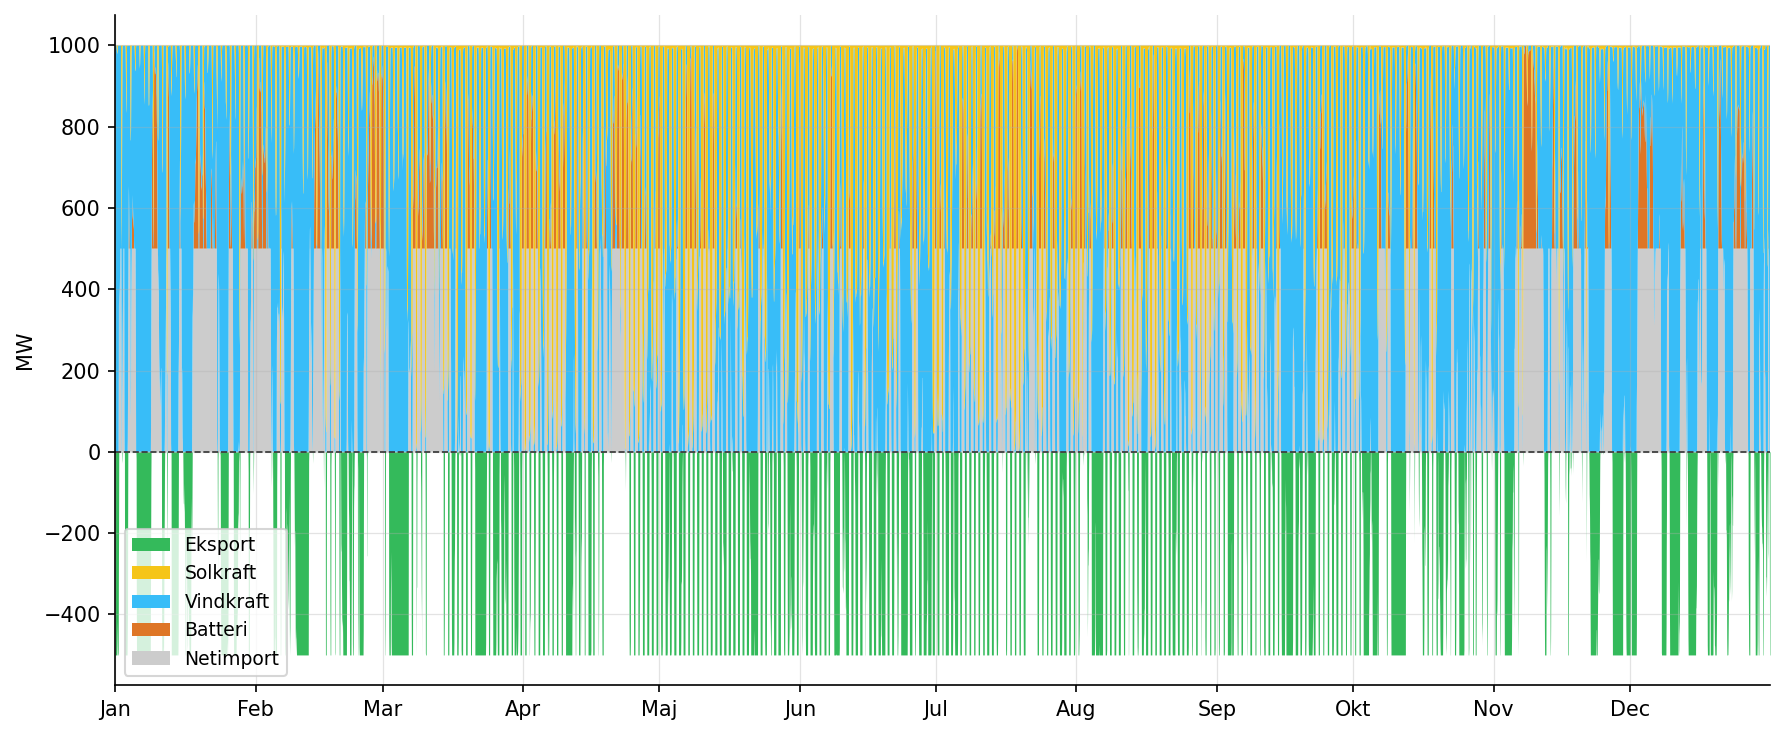

(<Figure size 1800x750 with 1 Axes>, <Axes: ylabel='MW'>)

In [13]:
# 4. timeplot
plot_dispatch(d, dates, ylabel='MW',
              save_path='figures/3_ve_dispatch_hourly.png')

# Aggregerede profiler

Samme fordelingsnøgle som timeplottet, aggregeret til dag, uge og måned for at fremhæve sæsonmønster uden timestøj.

*`5. daglig aggregering`*

*Summerer til 365 daglige MWh-totaler.*

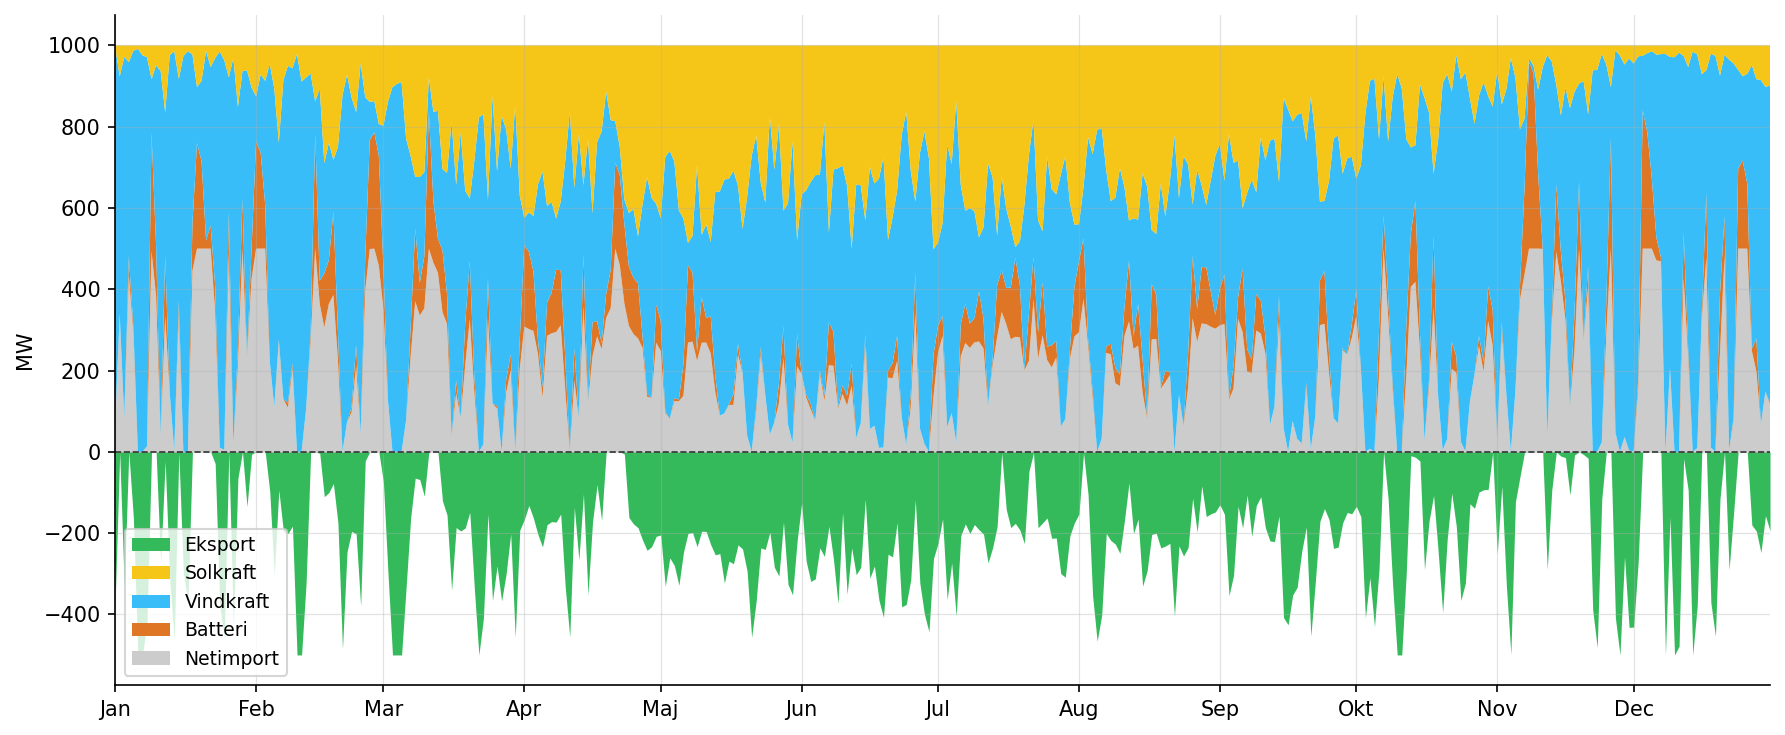

(<Figure size 1800x750 with 1 Axes>, <Axes: ylabel='MW'>)

In [14]:
# 5. daglig aggregering
d_day, idx_day = aggregate_dispatch(d, dates, 'D')
plot_dispatch(d_day, idx_day, ylabel='MW',
              save_path='figures/3_ve_dispatch_daily.png')

*`6. ugentlig aggregering`*

*Summerer til 52 ugentlige MWh-totaler.*

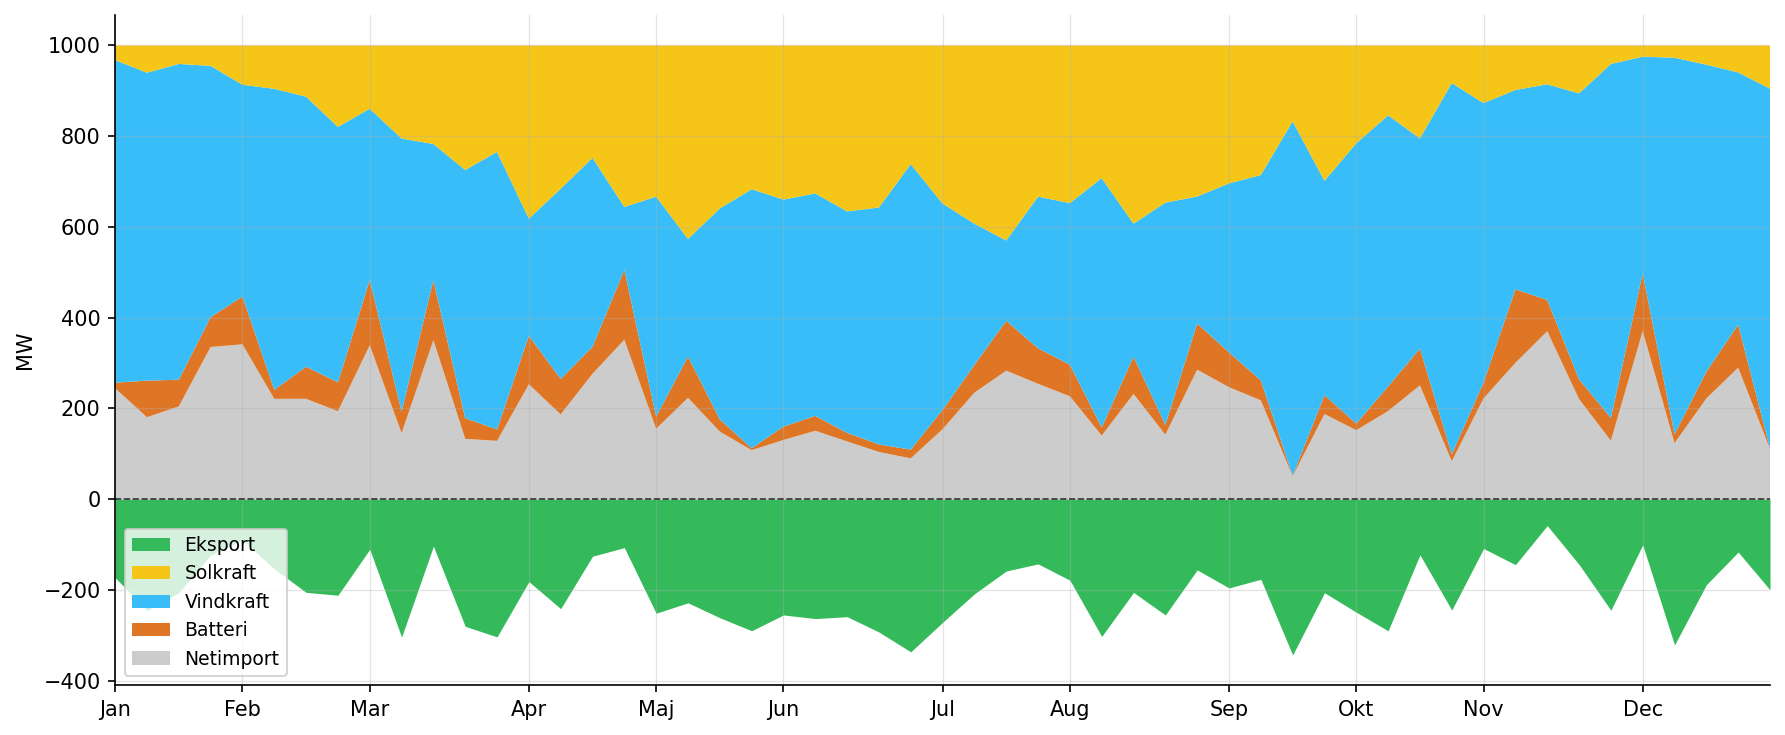

(<Figure size 1800x750 with 1 Axes>, <Axes: ylabel='MW'>)

In [15]:
# 6. ugentlig aggregering
d_week, idx_week = aggregate_dispatch(d, dates, 'W')
plot_dispatch(d_week, idx_week, ylabel='MW',
              save_path='figures/3_ve_dispatch_weekly.png')

*`7. månedlig aggregering`*

*Summerer til 12 månedlige MWh-totaler.*

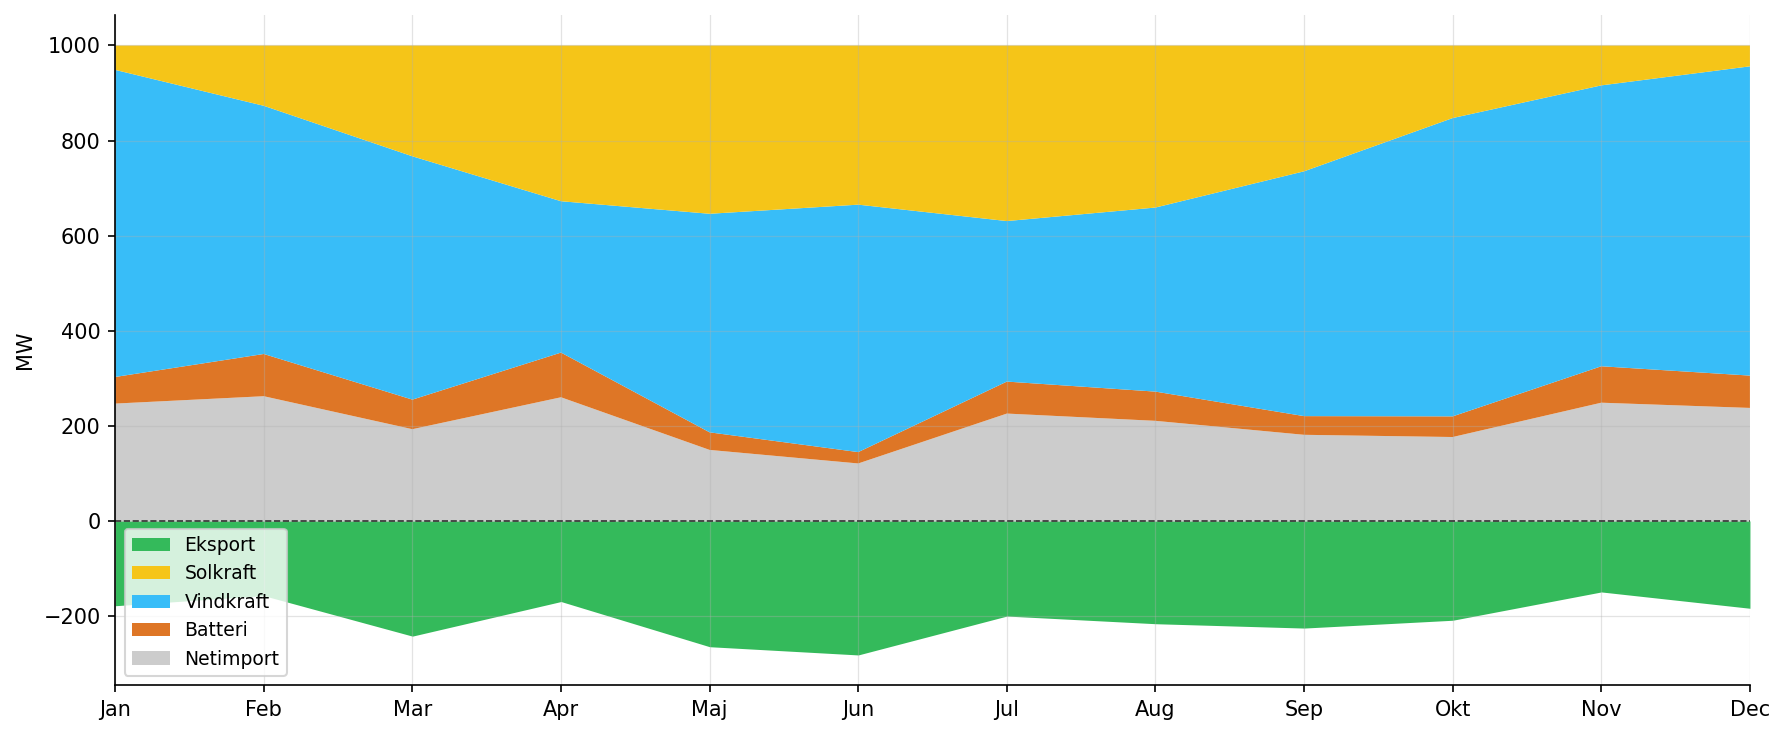

(<Figure size 1800x750 with 1 Axes>, <Axes: ylabel='MW'>)

In [16]:
# 7. månedlig aggregering
d_month, idx_month = aggregate_dispatch(d, dates, 'ME')
plot_dispatch(d_month, idx_month, ylabel='MW',
              save_path='figures/3_ve_dispatch_monthly.png')